In [7]:
import kagglehub
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# --- 1. LOADING DATA ---
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
file_path = os.path.join(path, "diabetes_012_health_indicators_BRFSS2015.csv")
df = pd.read_csv(file_path)

df["Diabetes_012"] = df["Diabetes_012"].replace({1:0,2:1})
df = df.rename(columns={"Diabetes_012": "Diabetes_binary"})

# --- 2. CLEANING: DUPLICATES & MISSING VALUES ---
print("--- CLEANING ---")
print("Missing values before cleaning:\n", df.isnull().sum().sum())
df = df.dropna() # Fulfills "handling of missing values"

print("Total number of duplicates:", df.duplicated().sum())
df = df.drop_duplicates() # Fulfills "cleaning of duplicates"
print(f"Shape after cleaning: {df.shape}\n")

# --- 3. TYPING OF VARIABLES ---
print("--- TYPING OF VARIABLES ---")
# Fulfills "Typing of variables" by converting float64 to int32 to save memory
df = df.astype('int32') 
print(df.dtypes.head(5), "\n") 

# --- 4. QUANTITATIVE EXPLORATORY ANALYSIS ---
print("--- QUANTITATIVE EDA ---")
# Fulfills "Quantitative exploratory analysis" (Statistical distribution)
display(df.describe()) 

# --- 5. SEPARATION (X and y) ---
X = df.drop("Diabetes_binary", axis = 1)
y = df["Diabetes_binary"]

# --- 6. SPLITTING THE DATASET ---
X_train, X_validtest, y_train, y_validtest = train_test_split(X, y, test_size = 0.3, random_state = 42, stratify = y)
X_val, X_test, y_val, y_test = train_test_split(X_validtest, y_validtest, test_size=0.5, random_state=42, stratify=y_validtest)
print(f"Training data: {X_train.shape[0]} | Validation: {X_val.shape[0]} | Testing: {X_test.shape[0]}\n")

# --- 7. NORMALIZATION ---
print("--- NORMALIZATION ---")
continuous_cols = ['BMI', 'PhysHlth', 'MentHlth'] 
scaler = StandardScaler()
X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_val[continuous_cols] = scaler.transform(X_val[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

# --- 8. SAVING CLEANED DATASET ---
os.makedirs('data_clean', exist_ok=True) 
X_train.to_csv('data_clean/X_train.csv', index=False)
X_val.to_csv('data_clean/X_val.csv', index=False)
X_test.to_csv('data_clean/X_test.csv', index=False)
y_train.to_csv('data_clean/y_train.csv', index=False)
y_val.to_csv('data_clean/y_val.csv', index=False)
y_test.to_csv('data_clean/y_test.csv', index=False)

print("Data successfully saved! Sprint 1 Data Prep is officially complete.")

--- CLEANING ---
Missing values before cleaning:
 0
Total number of duplicates: 24206
Shape after cleaning: (229474, 22)

--- TYPING OF VARIABLES ---
Diabetes_binary    int32
HighBP             int32
HighChol           int32
CholCheck          int32
BMI                int32
dtype: object 

--- QUANTITATIVE EDA ---


,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.00000,229474.000000,229474.000000,229474.000000,229474.000000,...,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000
mean,0.152945,0.454343,0.441640,0.959481,28.687507,0.46580,0.044816,0.103336,0.733042,0.612675,...,0.946011,0.092921,2.601820,3.509866,4.681219,0.185751,0.439087,8.085068,4.979741,5.888615
std,0.359936,0.497912,0.496584,0.197173,6.789204,0.49883,0.206899,0.304398,0.442371,0.487140,...,0.225996,0.290323,1.064962,7.717643,9.050877,0.388906,0.496277,3.094451,0.992989,2.092888
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.00000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,6.000000,4.000000,4.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.00000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,0.000000,0.000000,0.000000,0.000000,8.000000,5.000000,6.000000
75%,0.000000,1.000000,1.000000,1.000000,32.000000,1.00000,0.000000,0.000000,1.000000,1.000000,...,1.000000,0.000000,3.000000,2.000000,4.000000,0.000000,1.000000,10.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.00000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,5.000000,30.000000,30.000000,1.000000,1.000000,13.000000,6.000000,8.000000


Training data: 160631 | Validation: 34421 | Testing: 34422

--- NORMALIZATION ---
Data successfully saved! Sprint 1 Data Prep is officially complete.


In [8]:
import numpy as np

# Helper functions for the math
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def sigmoid_derivative(z):
    s = sigmoid(z)
    return s * (1 - s)

# 1. PROGRAM FORWARD PROPAGATION
def forward_propagation(X, W1, b1, W2, b2):
    """Passes the data forward through the network to make a guess."""
    # Layer 1 (Hidden)
    Z1 = np.dot(W1, X) + b1
    A1 = sigmoid(Z1)
    
    # Layer 2 (Output)
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)
    
    return Z1, A1, Z2, A2

# 2. PROGRAM COST FUNCTION
def compute_cost(A2, Y):
    """Calculates how wrong the model's guess was (Log-Loss)."""
    m = Y.shape[1] # Number of examples
    cost = -(1/m) * np.sum(Y * np.log(A2) + (1 - Y) * np.log(1 - A2))
    return cost

# 3. PROGRAM BACKWARD PROPAGATION
def backward_propagation(X, Y, Z1, A1, A2, W2):
    """Calculates the gradients (adjustments) to fix the model's errors."""
    m = X.shape[1]
    
    # Layer 2 adjustments
    dZ2 = A2 - Y
    dW2 = (1/m) * np.dot(dZ2, A1.T)
    db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)
    
    # Layer 1 adjustments
    dA1 = np.dot(W2.T, dZ2)
    dZ1 = dA1 * sigmoid_derivative(Z1)
    dW1 = (1/m) * np.dot(dZ1, X.T)
    db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)
    
    return dW1, db1, dW2, db2

print("Functions for Forward Prop, Cost, and Backprop successfully defined!")

Functions for Forward Prop, Cost, and Backprop successfully defined!


In [9]:
import numpy as np

# Fonction sigmoïde
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Fonction coût (log-loss)
def compute_cost(A, y):
    m = y.shape[0]
    # Small epsilon added to avoid log(0) errors
    cost = -(1/m) * np.sum(y * np.log(A + 1e-15) + (1 - y) * np.log(1 - A + 1e-15))
    return cost

# Régression logistique avec descente de gradient
def logistic_regression(X, y, alpha=0.01, n_iter=1000):
    m, n = X.shape
    
    # Ajouter une colonne de 1 à X pour le biais (bias)
    X = np.hstack((X, np.ones((m, 1))))
    
    # Initialiser les poids (weights)
    W = np.zeros((n + 1, 1))
    y = y.reshape(-1, 1)
    
    for i in range(n_iter):
        # Étape 1 : prédiction (Forward Prop)
        Z = np.dot(X, W)
        A = sigmoid(Z)
        
        # Étape 2 : coût
        cost = compute_cost(A, y)
        
        # Étape 3 : gradient
        grad = (1/m) * np.dot(X.T, (A - y))
        
        # Étape 4 : mise à jour (Gradient Descent)
        W -= alpha * grad
        
        # Optionnel : afficher le coût toutes les 100 itérations
        if i % 100 == 0:
            print(f"Iteration {i}, coût = {cost:.4f}")
            
    return W

# Exemple d'utilisation
if __name__ == "__main__":
    # Données factices (X : 2 features, y : labels 0/1)
    X = np.array([
        [0.5, 1.5],
        [1.0, 1.8],
        [2.0, 2.5],
        [3.0, 3.5],
        [4.0, 4.5]
    ])
    
    y = np.array([0, 0, 0, 1, 1]) # Labels
    
    # Entraînement du modèle
    W = logistic_regression(X, y, alpha=0.1, n_iter=1000)
    
    print("\nParamètres finaux (W) :")
    print(W)

Iteration 0, coût = 0.6931
Iteration 100, coût = 0.3823
Iteration 200, coût = 0.2808
Iteration 300, coût = 0.2306
Iteration 400, coût = 0.2000
Iteration 500, coût = 0.1790
Iteration 600, coût = 0.1633
Iteration 700, coût = 0.1510
Iteration 800, coût = 0.1411
Iteration 900, coût = 0.1327

Paramètres finaux (W) :
[[ 3.17421928]
 [-0.87676546]
 [-5.03648975]]


In [10]:
import numpy as np

def sigmoid(z): return 1/(1+np.exp(-z))

# données
x = np.array([[0.7, 0.9]])
y = np.array([[1.0]])

W1 = np.array([[0.3, -0.2],[0.6, 0.1]])
b1 = np.array([[0.0, 0.1]])
W2 = np.array([[0.4],[-0.3]])
b2 = np.array([[0.05]])
alpha = 0.1

# forward
Z1 = x.dot(W1) + b1
A1 = sigmoid(Z1)
Z2 = A1.dot(W2) + b2
A2 = sigmoid(Z2)
cost = - (y*np.log(A2) + (1-y)*np.log(1-A2))

# backward
dZ2 = A2 - y
dW2 = A1.T.dot(dZ2)
db2 = dZ2
dA1 = dZ2.dot(W2.T)
dZ1 = dA1 * (A1 * (1 - A1))
dW1 = x.T.dot(dZ1)
db1 = dZ1

# update
W1 -= alpha * dW1
b1 -= alpha * db1
W2 -= alpha * dW2
b2 -= alpha * db2

print("A2 =", A2)
print("cost =", cost)
print("dW1 =", dW1)
print("dW2 =", dW2)
print("W1_new =", W1)
print("W2_new =", W2)

A2 = [[0.5418822]]
cost = [[0.61270665]]
dW1 = [[-0.02795004  0.02403616]
 [-0.03593577  0.03090363]]
dW2 = [[-0.31114385]
 [-0.23478418]]
W1_new = [[ 0.302795   -0.20240362]
 [ 0.60359358  0.09690964]]
W2_new = [[ 0.43111439]
 [-0.27652158]]


Generating EDA Graphs...


C:\Users\Hp\AppData\Local\Temp\ipykernel_3040\4171786478.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='Diabetes_binary', palette='Set2', ax=axes[0])
C:\Users\Hp\AppData\Local\Temp\ipykernel_3040\4171786478.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Diabetes_binary', y='BMI', palette='Set2', ax=axes[1])


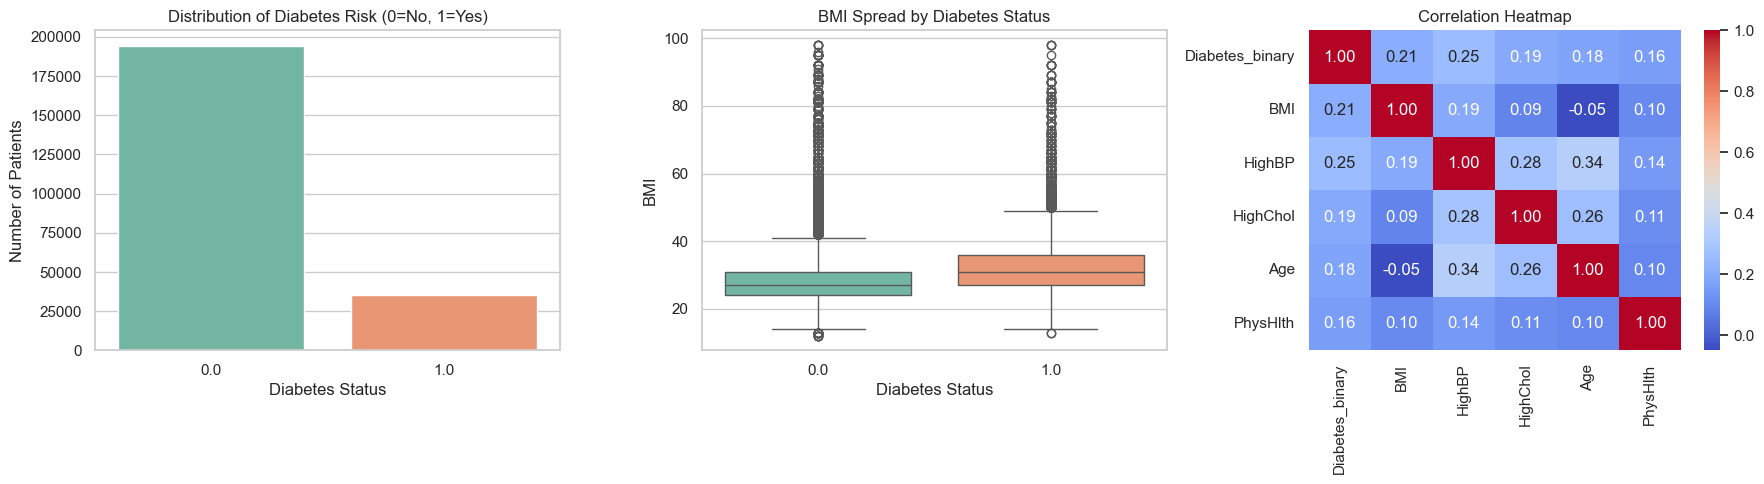

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import kagglehub

# 1. Load the data (using your existing kagglehub setup)
path = kagglehub.dataset_download("alexteboul/diabetes-health-indicators-dataset")
file_path = os.path.join(path, "diabetes_012_health_indicators_BRFSS2015.csv")
df = pd.read_csv(file_path)

# 2. Prep the target variable so the graphs make sense
df["Diabetes_012"] = df["Diabetes_012"].replace({1:0, 2:1})
df = df.rename(columns={"Diabetes_012": "Diabetes_binary"})
df = df.drop_duplicates()

# --- 3. GENERATE THE EDA GRAPHS ---
print("Generating EDA Graphs...")

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Graph 1: The Class Imbalance (Target Distribution)
sns.countplot(data=df, x='Diabetes_binary', palette='Set2', ax=axes[0])
axes[0].set_title('Distribution of Diabetes Risk (0=No, 1=Yes)')
axes[0].set_xlabel('Diabetes Status')
axes[0].set_ylabel('Number of Patients')

# Graph 2: BMI vs Diabetes Risk (Clinical Proof)
sns.boxplot(data=df, x='Diabetes_binary', y='BMI', palette='Set2', ax=axes[1])
axes[1].set_title('BMI Spread by Diabetes Status')
axes[1].set_xlabel('Diabetes Status')
axes[1].set_ylabel('BMI')

# Graph 3: Feature Correlation Heatmap
# Selecting a few key columns so the heatmap is readable
cols_to_check = ['Diabetes_binary', 'BMI', 'HighBP', 'HighChol', 'Age', 'PhysHlth']
correlation_matrix = df[cols_to_check].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", ax=axes[2])
axes[2].set_title('Correlation Heatmap')

# Display the graphs
plt.tight_layout()
plt.show()